# Adversarial Detection via Mahalanobis Distance

This notebook builds a lightweight **adversarial example detector** using the same idea already explored visually in `latent_space/PCA_*.ipynb`: adversarial perturbations push an image's internal representation away from the manifold of natural images. Instead of just plotting that shift, we turn it into a binary classifier.

Following Lee et al. (2018, *"A Simple Unified Framework for Detecting Out-of-Distribution Samples"*), we fit a Gaussian distribution over the penultimate-layer features of clean images and flag any input whose feature vector lies too far away (in **Mahalanobis distance**) as adversarial. Unlike the preprocessing defenses, this technique does not try to *cure* the attack: it only tells us **whether an input should be trusted at all**, which is what a real serving pipeline actually needs (route suspicious inputs to a fallback, log them, or reject them outright).

**Simplification vs. the original paper:** Lee et al. fit one Gaussian *per class*. `images/miniimagenet_random_100/` only has ~1 image per class, nowhere near enough to estimate a 1000-way class-conditional covariance. We instead fit a **single global Gaussian** over all clean features (after a PCA reduction, exactly as in `latent_space/`, to keep the covariance well-conditioned), a coarser but still effective novelty-detection signal, and an honest reflection of what this repo's sample data actually supports.


In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os
from PIL import Image
from sklearn.decomposition import PCA
from sklearn.covariance import LedoitWolf
from sklearn.metrics import roc_auc_score, roc_curve

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

### Setup
We demonstrate on **MobileNetV2** for speed, since the technique applies identically to any model in the repo. The feature extractor reuses the network up to (and including) its `GlobalAveragePooling2D` layer, i.e. everything except the final 1000-way classification head.

In [2]:
TARGET_SIZE = (224, 224)

base_model = MobileNetV2(weights='imagenet')
base_model.trainable = False

# Penultimate layer: MobileNetV2's GlobalAveragePooling2D output (1280-d), right before the classification head
feature_extractor = tf.keras.Model(inputs=base_model.input, outputs=base_model.layers[-2].output)

def load_and_preprocess_image(img_path, target_size=TARGET_SIZE):
    img_raw = tf.io.read_file(img_path)
    img = tf.image.decode_image(img_raw, channels=3)
    img = tf.cast(img, tf.float32)
    img = tf.image.resize(img, target_size)
    img = preprocess_input(img)
    return tf.expand_dims(img, axis=0)

def extract_features(img_path):
    return feature_extractor(load_and_preprocess_image(img_path), training=False).numpy().flatten()

### Clean Feature Bank
We extract features for every image in `images/miniimagenet_random_100/` and split them into a **fit set** (used to estimate the Gaussian) and a **held-out clean test set** (used only for ROC evaluation, so the detector is never tested on data it was calibrated with).

In [3]:
clean_paths = sorted(glob.glob('../images/miniimagenet_random_100/*.*'))
clean_features = np.stack([extract_features(p) for p in clean_paths])
print(f"Extracted features for {len(clean_paths)} clean images - shape {clean_features.shape}")

rng = np.random.default_rng(seed=42)
perm = rng.permutation(len(clean_paths))
split = int(0.7 * len(clean_paths))
fit_idx, test_idx = perm[:split], perm[split:]

clean_fit_features = clean_features[fit_idx]
clean_test_features = clean_features[test_idx]
print(f"Fit set: {len(fit_idx)} images | Held-out clean test set: {len(test_idx)} images")

Extracted features for 100 clean images - shape (100, 1280)
Fit set: 70 images | Held-out clean test set: 30 images


### Fit the Gaussian in PCA Space
The raw feature space is 1280-dimensional with only ~70 fit samples, far too few to estimate a full covariance matrix. We first project to a much lower-dimensional PCA subspace (same tool used throughout `latent_space/`), then fit a shrinkage-regularized Gaussian (`LedoitWolf`) in that subspace.

In [4]:
N_COMPONENTS = min(20, len(fit_idx) - 1)

pca = PCA(n_components=N_COMPONENTS, random_state=42)
clean_fit_pca = pca.fit_transform(clean_fit_features)
print(f"PCA retains {pca.explained_variance_ratio_.sum() * 100:.1f}% of variance with {N_COMPONENTS} components")

gaussian = LedoitWolf().fit(clean_fit_pca)

def mahalanobis_scores(features):
    """Mahalanobis distance of each feature vector to the fitted clean-image Gaussian, in PCA space."""
    features_pca = pca.transform(features)
    diff = features_pca - gaussian.location_
    inv_cov = np.linalg.inv(gaussian.covariance_)
    return np.sqrt(np.einsum('ij,jk,ik->i', diff, inv_cov, diff))

PCA retains 54.5% of variance with 20 components


### Adversarial Feature Bank
We reuse the MobileNetV2 adversarial examples already generated by `robustness_evaluation/10_generate_adversarial_dataset.ipynb`, using only the ones that actually succeeded, since an unsuccessful attack is not a meaningful detection target.

In [5]:
manifest_df = pd.read_csv('../robustness_evaluation/adversarial_dataset_manifest.csv')
adv_rows = manifest_df[(manifest_df['Model'] == 'MobileNetV2') & (manifest_df['Success'])]

adv_features = []
for _, row in adv_rows.iterrows():
    img_path = f"../robustness_evaluation/adversarial_examples/MobileNetV2/{row['Attack']}/{row['Image_ID']}.png"
    if os.path.exists(img_path):
        adv_features.append(extract_features(img_path))

adv_features = np.stack(adv_features) if adv_features else np.empty((0, clean_features.shape[1]))
print(f"Extracted features for {len(adv_features)} successful adversarial examples")

Extracted features for 228 successful adversarial examples


### Detection Performance (ROC / AUROC)
Labels: `1` = adversarial, `0` = clean. We score the held-out clean test set and the adversarial set with the same Mahalanobis distance and report the ROC curve and AUROC, the standard way to evaluate a detector independently of any single distance threshold.

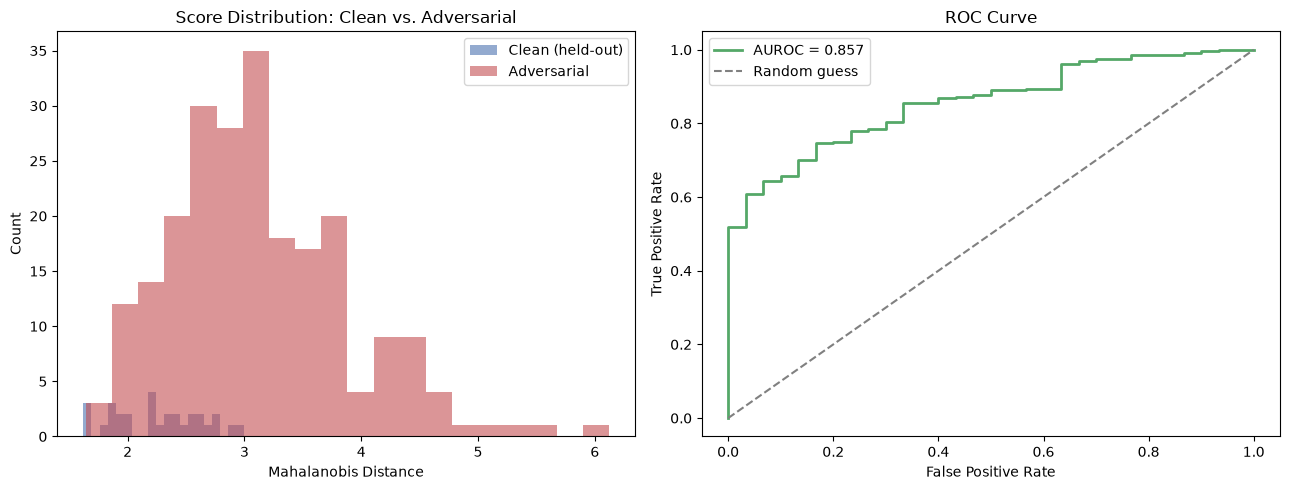

AUROC: 0.8573


In [6]:
clean_test_scores = mahalanobis_scores(clean_test_features)
adv_scores = mahalanobis_scores(adv_features) if len(adv_features) > 0 else np.array([])

y_true = np.concatenate([np.zeros(len(clean_test_scores)), np.ones(len(adv_scores))])
y_score = np.concatenate([clean_test_scores, adv_scores])

auroc = roc_auc_score(y_true, y_score)
fpr, tpr, thresholds = roc_curve(y_true, y_score)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(clean_test_scores, bins=20, alpha=0.6, label='Clean (held-out)', color='#4C72B0')
axes[0].hist(adv_scores, bins=20, alpha=0.6, label='Adversarial', color='#C44E52')
axes[0].set_xlabel('Mahalanobis Distance')
axes[0].set_ylabel('Count')
axes[0].set_title('Score Distribution: Clean vs. Adversarial')
axes[0].legend()

axes[1].plot(fpr, tpr, color='#55A868', linewidth=2, label=f'AUROC = {auroc:.3f}')
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"AUROC: {auroc:.4f}")